# Unemployment Analysis in India — Pre & Post COVID-19

**CodeAlpha Data Science Internship — Task 2** &nbsp;|&nbsp; **Tools:** Python, Pandas, Seaborn, Scikit-learn

This notebook is a thin, narrative wrapper around the reusable code in `src/`
(`data_cleaning.py`, `analysis.py`, `visualization.py`). All the real logic
lives there so it can be tested, reused, and run headlessly via `src/main.py`
— this notebook just calls it and tells the story.

### Objective
1. Clean and explore India's regional unemployment-rate data
2. Quantify the impact of the COVID-19 lockdown on employment
3. Identify seasonal / monthly unemployment patterns
4. Apply **machine learning** (Random Forest regression + K-Means clustering)
5. Translate the findings into **policy-relevant recommendations**

### Datasets
| File | Coverage | Granularity | Extra fields |
|---|---|---|---|
| `Unemployment in India.csv` | May 2019 – Jun 2020 | State × **Rural/Urban** | Labour participation rate |
| `Unemployment_Rate_upto_11_2020.csv` | Jan 2020 – Oct 2020 | State × **Zone** (geo) | Longitude / Latitude, Zone |


## 1. Setup


In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path("..", "src").resolve()))

import pandas as pd
import matplotlib.pyplot as plt

from data_cleaning import load_clean_data
from analysis import (
    area_comparison, state_ranking, zone_ranking,
    monthly_national_average, covid_period_summary, state_covid_impact,
    seasonal_pattern, recovery_curve,
    train_unemployment_regressor, cluster_states_by_risk,
)
from visualization import (
    plot_distribution, plot_state_ranking, plot_zone_ranking,
    plot_covid_trend, plot_state_impact, plot_seasonal_pattern,
    plot_recovery_curve, plot_model_performance, plot_clusters,
)

pd.set_option("display.max_columns", None)


## 2. Load & Clean the Data


In [2]:
df1, df2 = load_clean_data()

print("Dataset 1 (India, Rural/Urban):", df1.shape)
print("Dataset 2 (2020, Zone/Geo):    ", df2.shape)
print("Dataset 1 date range:", df1.Date.min().date(), "to", df1.Date.max().date())
print("Dataset 2 date range:", df2.Date.min().date(), "to", df2.Date.max().date())


Dataset 1 (India, Rural/Urban): (740, 10)
Dataset 2 (2020, Zone/Geo):     (267, 12)
Dataset 1 date range: 2019-05-31 to 2020-06-30
Dataset 2 date range: 2020-01-31 to 2020-10-31


In [3]:
df1.head()


,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Area,Year,Month,Month_Name
0,Andhra Pradesh,2019-05-31,Monthly,3.65,11999139.0,43.24,Rural,2019,5,May
1,Telangana,2019-05-31,Monthly,2.23,11053353.0,61.74,Rural,2019,5,May
2,Tamil Nadu,2019-05-31,Monthly,0.97,15844698.0,49.44,Rural,2019,5,May
3,Rajasthan,2019-05-31,Monthly,4.03,15226005.0,38.52,Rural,2019,5,May
4,Punjab,2019-05-31,Monthly,9.17,6088547.0,44.79,Rural,2019,5,May


In [4]:
df2.head()


,Region,Date,Frequency,Unemployment_Rate,Employed,Labour_Participation_Rate,Zone,longitude,latitude,Year,Month,Month_Name
0,Andhra Pradesh,2020-01-31,M,5.48,16635535,41.02,South,15.9129,79.7400,2020,1,January
1,Tripura,2020-01-31,M,32.67,1508130,69.69,Northeast,23.9408,91.9882,2020,1,January
2,Delhi,2020-01-31,M,22.23,5805284,47.79,North,28.7041,77.1025,2020,1,January
3,Telangana,2020-01-31,M,5.49,17609295,59.25,South,18.1124,79.0193,2020,1,January
4,Tamil Nadu,2020-01-31,M,1.57,26881641,41.96,South,11.1271,78.6569,2020,1,January


## 3. Exploratory Data Analysis

`data_cleaning.py` already fixed the whitespace/date quirks straight from the
source. Here we look at the cleaned distributions.


In [5]:
df1[["Unemployment_Rate", "Employed", "Labour_Participation_Rate"]].describe()


,Unemployment_Rate,Employed,Labour_Participation_Rate
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


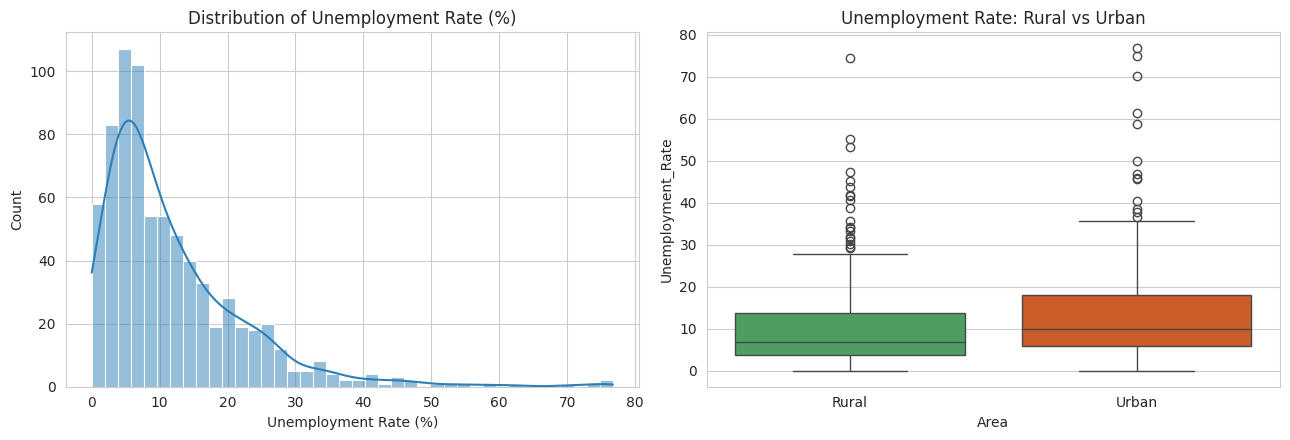

In [6]:
fig = plot_distribution(df1)
plt.show()


In [7]:
area_avg = area_comparison(df1)
print(area_avg)
print(f"\nUrban unemployment runs {area_avg['Urban'] - area_avg['Rural']:.2f} pp higher than rural on average.")


Area
Rural    10.32
Urban    13.17
Name: Unemployment_Rate, dtype: float64

Urban unemployment runs 2.85 pp higher than rural on average.


**Which states run the highest / lowest average unemployment?**


Top 5 highest:
 Region
Tripura             28.35
Haryana             26.28
Jharkhand           20.58
Bihar               18.92
Himachal Pradesh    18.54
Name: Unemployment_Rate, dtype: float64

Top 5 lowest:
 Region
Gujarat        6.66
Uttarakhand    6.58
Assam          6.43
Odisha         5.66
Meghalaya      4.80
Name: Unemployment_Rate, dtype: float64


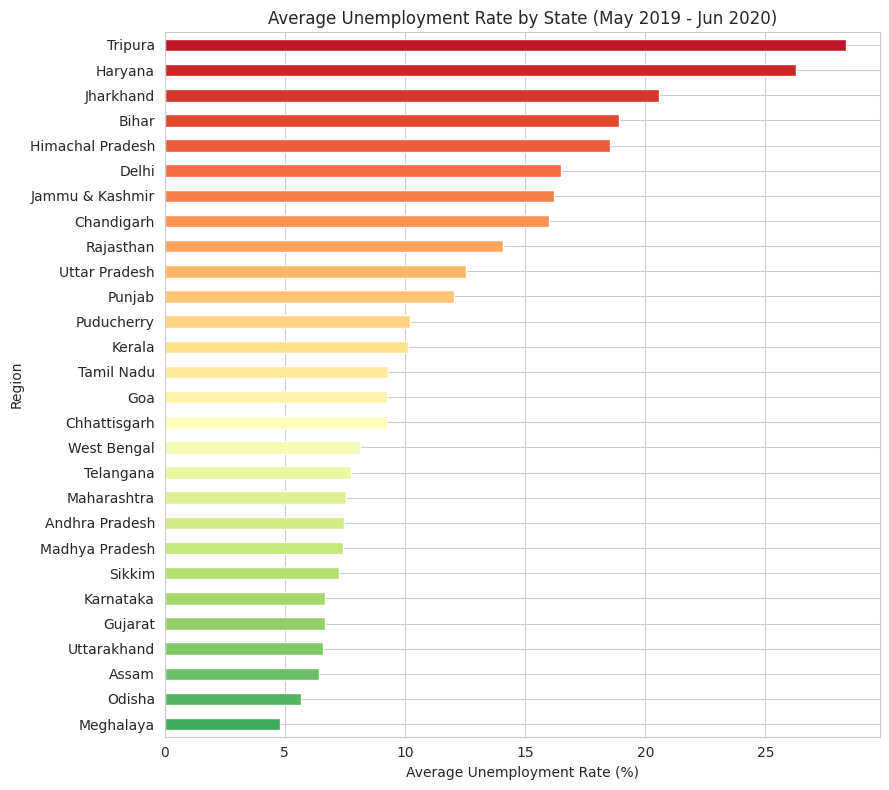

In [8]:
state_avg = state_ranking(df1)
fig = plot_state_ranking(state_avg)
plt.show()

print("Top 5 highest:\n", state_avg.head(5))
print("\nTop 5 lowest:\n", state_avg.tail(5))


**Zone-level view** (dataset 2 groups states into 5 geographic zones).


Zone
North        15.89
East         13.92
Northeast    10.95
South        10.45
West          8.24
Name: Unemployment_Rate, dtype: float64


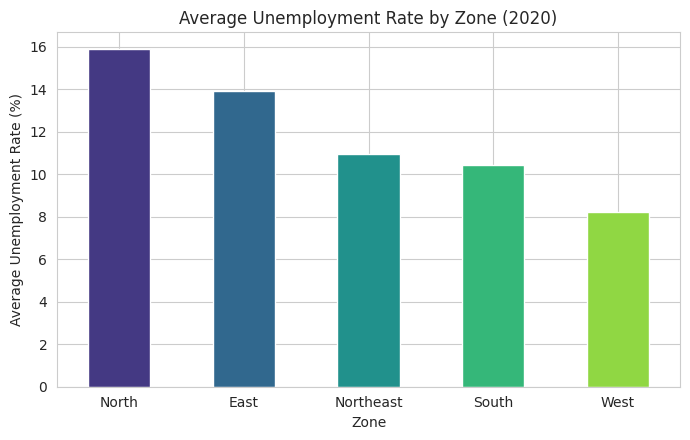

In [9]:
zone_avg = zone_ranking(df2)
fig = plot_zone_ranking(zone_avg)
plt.show()
print(zone_avg)


## 4. COVID-19 Impact Analysis

India's nationwide lockdown began **25 March 2020**. We compare the national
monthly average unemployment rate before, during, and after that point.


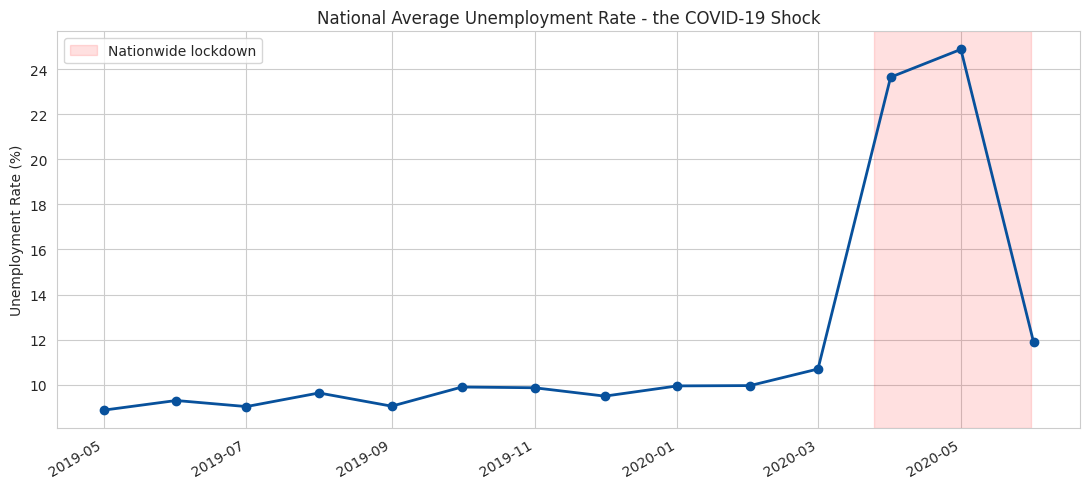

In [10]:
monthly_natl = monthly_national_average(df1)
fig = plot_covid_trend(monthly_natl)
plt.show()


In [11]:
covid_summary = covid_period_summary(df1)
print(covid_summary)
print(f"\nUnemployment rate rose {covid_summary['During lockdown'] - covid_summary['Pre-lockdown']:.2f} "
      f"percentage points during the lockdown.")


Pre-lockdown               9.51
During lockdown           19.68
Post-lockdown (Jun-20)    11.90
dtype: float64

Unemployment rate rose 10.17 percentage points during the lockdown.


**Which states were hit hardest?** (peak lockdown month vs. each state's pre-COVID baseline)


Region
Puducherry    74.03
Tamil Nadu    46.53
Bihar         38.10
Jharkhand     37.32
Karnataka     25.91
Name: Unemployment_Rate, dtype: float64


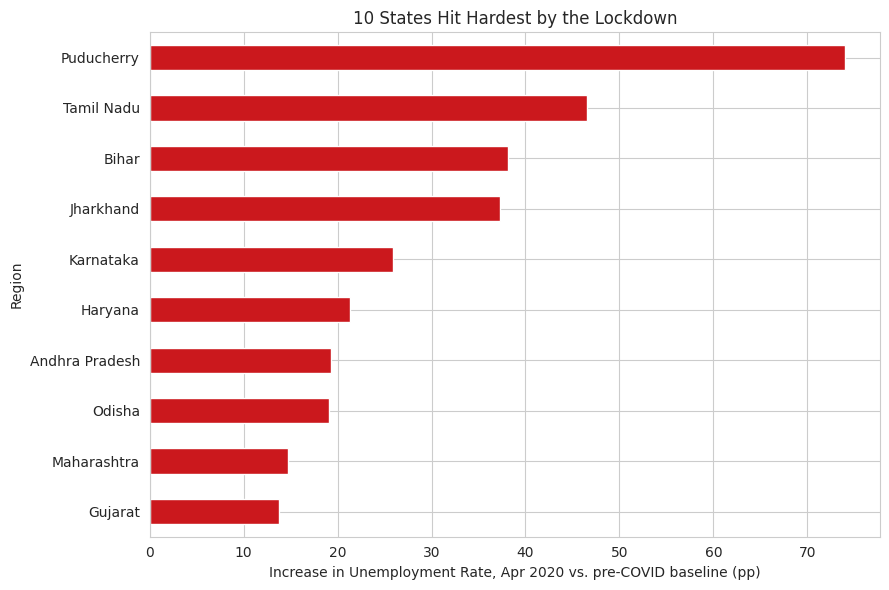

In [12]:
impact = state_covid_impact(df1)
fig = plot_state_impact(impact)
plt.show()
print(impact.head(5))


## 5. Seasonal Trends

With ~14 months of data we can already see a month-of-year pattern emerging
independent of the one-off COVID shock.


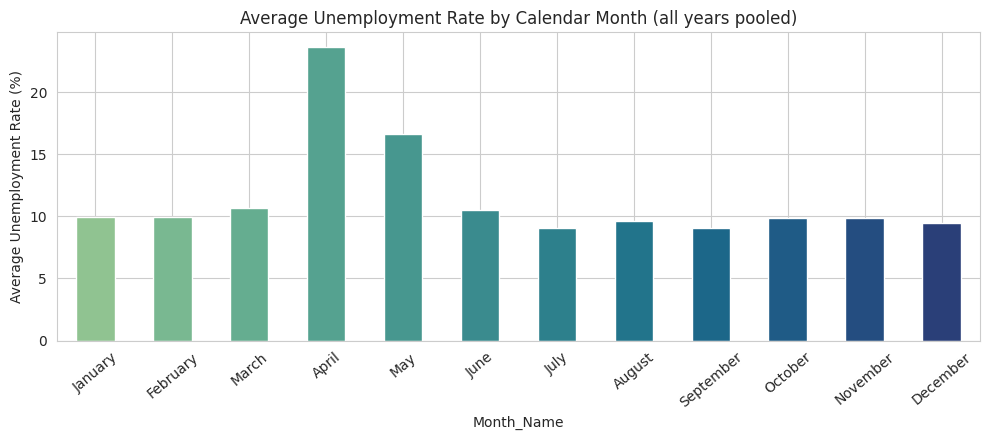

In [13]:
pattern = seasonal_pattern(df1)
fig = plot_seasonal_pattern(pattern)
plt.show()


**Post-lockdown recovery curve** using dataset 2, which extends through October 2020.


Date
2020-01-01     9.20
2020-02-01     9.27
2020-03-01    10.78
2020-04-01    22.24
2020-05-01    23.24
2020-06-01    10.91
2020-07-01     9.83
2020-08-01    10.31
2020-09-01     8.71
2020-10-01     8.03
Freq: MS, Name: Unemployment_Rate, dtype: float64


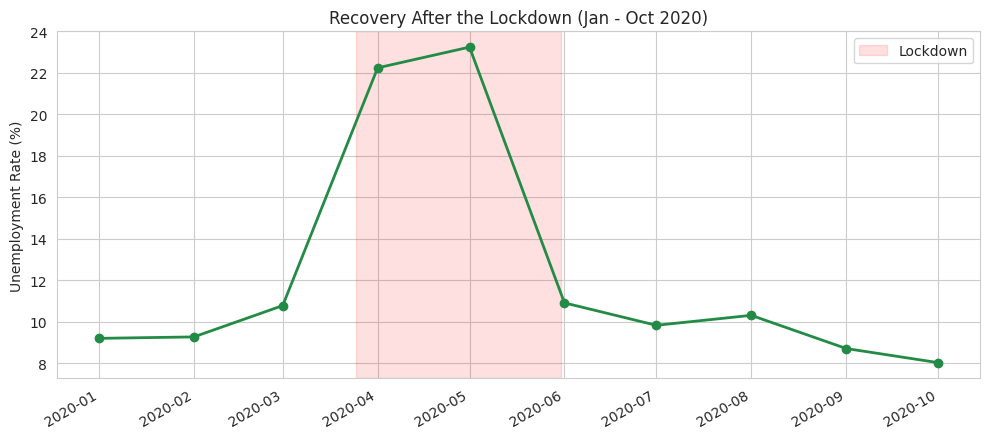

In [14]:
recovery = recovery_curve(df2)
fig = plot_recovery_curve(recovery)
plt.show()
print(recovery)


## 6. Machine Learning — Predicting Unemployment Rate

**Algorithm:** Random Forest Regressor. **Features:** state, area (rural/urban),
month, year, number employed, and labour participation rate. **Target:**
unemployment rate. (Implementation: `analysis.train_unemployment_regressor`.)


In [15]:
reg = train_unemployment_regressor(df1)
print(f"R-squared : {reg.r2:.3f}")
print(f"RMSE      : {reg.rmse:.2f} pp")
print(f"MAE       : {reg.mae:.2f} pp")


R-squared : 0.641
RMSE      : 5.90 pp
MAE       : 3.32 pp


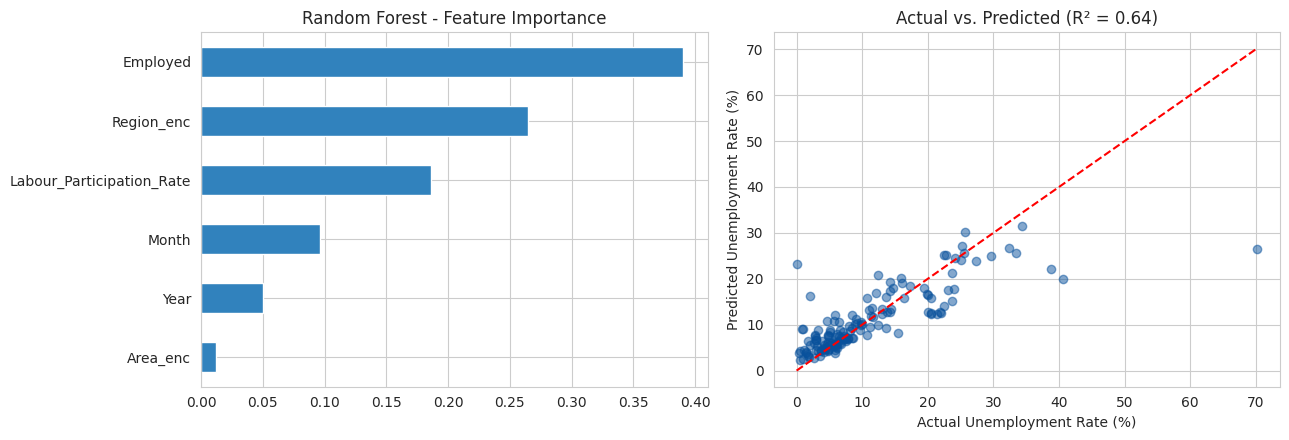

In [16]:
fig = plot_model_performance(reg)
plt.show()


## 7. Machine Learning — Clustering States by Risk Profile

**Algorithm:** K-Means (k=3). Groups states into **Low / Moderate / High**
unemployment-risk clusters using their 2020 averages — useful for
prioritising where policy intervention is most needed.
(Implementation: `analysis.cluster_states_by_risk`.)


In [17]:
state_features = cluster_states_by_risk(df2)
print(state_features["Risk_Level"].value_counts())


Risk_Level
High Risk        13
Low Risk         11
Moderate Risk     3
Name: count, dtype: int64


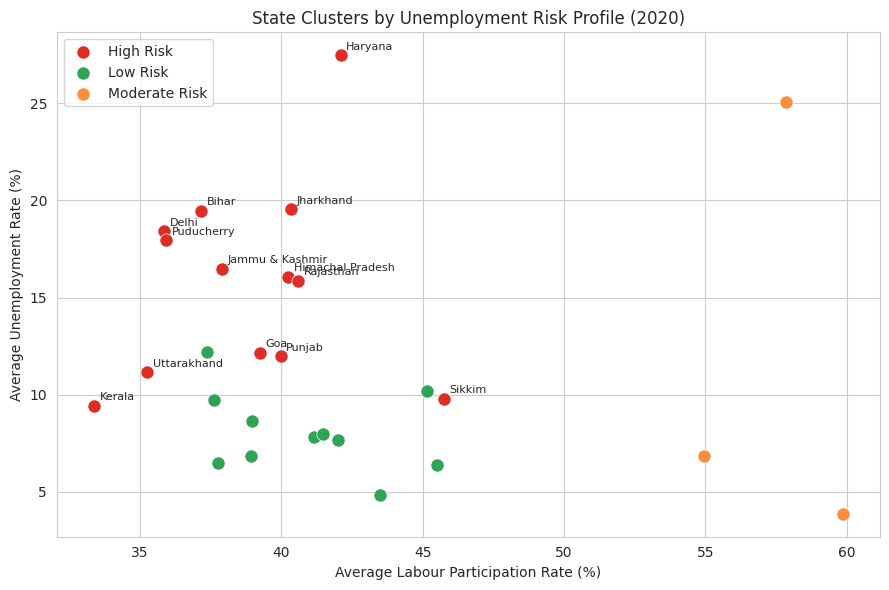

In [18]:
fig = plot_clusters(state_features)
plt.show()


In [19]:
state_features.sort_values("Avg_Unemployment", ascending=False)[
    ["Region", "Avg_Unemployment", "Avg_Participation", "Risk_Level"]
].reset_index(drop=True)


,Region,Avg_Unemployment,Avg_Participation,Risk_Level
0,Haryana,27.477000,42.100000,High Risk
1,Tripura,25.055000,57.848000,Moderate Risk
2,Jharkhand,19.539000,40.356000,High Risk
3,Bihar,19.471000,37.173000,High Risk
4,Delhi,18.414000,35.857000,High Risk
5,Puducherry,17.942000,35.918000,High Risk
6,Jammu & Kashmir,16.477778,37.894444,High Risk
7,Himachal Pradesh,16.065000,40.252000,High Risk
8,Rajasthan,15.868000,40.591000,High Risk
9,Tamil Nadu,12.187000,37.383000,Low Risk


## 8. Key Insights

1. **COVID-19 shock was severe but short-lived.** National unemployment jumped from a
   ~9-10% baseline to **~24% during the April–May 2020 lockdown** — roughly a
   **2.5x spike** — before partially recovering to single digits by September–October 2020.
2. **Urban areas were hit harder than rural areas** (≈13.2% vs ≈10.3% average), likely
   reflecting greater reliance on in-person services, retail, and informal urban labour
   that lockdowns disrupted directly.
3. **Impact was highly uneven across states.** A handful of states (e.g. Puducherry,
   Tamil Nadu, Bihar, Jharkhand) saw the steepest April-2020 spikes, while states like
   Meghalaya, Assam, Gujarat and Odisha stayed in single digits all year — pointing to
   structural/regional differences in resilience.
4. **A mild seasonal pattern exists independent of COVID**, with unemployment trending
   slightly higher in the latter half of the calendar year.
5. **Number employed and state identity are the strongest predictors** of unemployment
   rate in the Random Forest model (R² ≈ 0.64, MAE ≈ 3.3pp on held-out data) — ahead of
   labour participation rate — suggesting state-specific structural factors, not just
   workforce participation, drive a large share of the variation.
6. **K-Means clustering cleanly separates a "High Risk" group of states** (13 of 27)
   that combine high unemployment with lower labour participation — these are natural
   first targets for employment-guarantee schemes or skill-development programs.

## 9. Policy Recommendations

- **Targeted relief for "High Risk" states** identified by the clustering model (emergency
  employment schemes, MSME credit support) rather than a uniform national response.
- **Urban-focused safety nets** (gig/informal worker support funds) given the larger urban
  shock observed.
- **Early-warning monitoring**: the sharp, fast-moving April 2020 spike shows the value of
  **monthly** (vs. quarterly) unemployment tracking to enable faster policy response in
  future shocks.
- **Pre-emptive seasonal planning** around the months that historically run hotter, e.g.
  staggering public-works hiring to offset seasonal slack.

---
*Dataset source: Centre for Monitoring Indian Economy (CMIE), via Kaggle ("Unemployment in India").*
*Full written report: [`report/Unemployment_Analysis_Report.md`](../report/Unemployment_Analysis_Report.md)*
